In [1]:
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import PolynomialLR
from torch.utils.data import WeightedRandomSampler
from torchvision.transforms import v2

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm.notebook import tqdm
import json
import cv2
import numpy as np
###IE###
%load_ext autoreload
%autoreload 2
from utils.helpers import  plot_some_images ,read_images , pre_hard_skeletonize , pre_soft_skeletonize,compute_confution_matrix
from utils.preprocessing import WhiteTopHat , CLAHE , normalize_xca
from utils.dataset import  UnetDataset , ValidUnetDataset
from models.nnunet import nnUnet
from models.nnunet_blocks import nnUnetv2
from utils.losses import UnetLoss
from utils.recorder import HistoryRecorder
from logger import save_full_report
from trainer import trainer
###SS###

# Training

In [ ]:
args = {
    "base_path" : "../arcade/nnUnet_dataset/syntax",
    "in_c" : 1,
    "base_channel" :32,
    "image_shape" : (448,448),
    "class_count" : 26 ,
    "attention" : True,
    "k":40,
    "batch_size" : 10,
    "num_workers" : 10,
    "device" : "cuda" if torch.cuda.is_available() else "cpu",
    "lr" : 0.01,
    "momentum" : 0.99,
    "weight_decay" : 3e-5,
    "epcohs":200,
    "f_int_scale" : 2,
    "full_report_cycle" : 10,
    "max_channels":512,
    "input_channels":1,
    "unet_depth":6,
    "loss_type":"tversky loss",
    "alpha":0.3,
    "beta":0.7,
    "t_gamma":2.00,
    "f_gamma":2.0,
    "f_loss_scale":1,
    "loss_coefs":{"CE":1.0,"Second":1.0},
    "output_base_path" : "./outputs",
    "name" : "Attention7-DSV-tev-new_augs-binary2color-FCE",
    "deep_super_vision" : True,
    "f_alpha":None
}
class_map = {
    1: '1',2: '2', 3: '3',4: '4',
    5: '5',6: '6',7: '7',8: '8',
    9: '9',10: '9a',11: '10',12: '10a',
    13: '11',14: '12',15: '12a',16: '13',
    17: '14',18: '14a',19: '15',20: '16',
    21: '16a',22: '16b',23: '16c',
    24: '12b',25: '14b'
}
train_class_counts = [
    1000,374,375,369,303,525,525,
    340,310,198,70,21,1,320,61,
    129,305,107,49,38,232,43,48,31,63,127
]
# losses_keys = ["total loss","FCE loss",args["loss_type"]]
losses_keys = ["total loss","FCE loss",args["loss_type"]]
out_counts = 6 if args["deep_super_vision"] else 1
loss_weights = [1/(2**i) for i in range(out_counts)]
loss_weights

[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125]

In [ ]:
def class_weighting(method,class_counts,**kwargs):
    if(kwargs["use_pixel_counts"]):
        print("using pixel counts")
        with open("./data/train_class_counts.json","r") as f:
            train_class_counts = json.load(f)
        counts = [0]*(len(train_class_counts))
        for k,v in train_class_counts.items():
            counts[int(k)] = int(v)
        counts = np.array(counts,dtype=np.float64)
    else :
        print("using class counts")
        counts = np.array(class_counts,dtype=np.float64)

    if(method=="median"):
        print("median weights being used")
        median_count = np.median(counts)
        weights = median_count/np.array(counts)
        
    elif(method=="log"):
        print("log weights being used")
        total = np.sum(counts)
        weights = np.log(total/np.array(counts))
        weights = (weights / weights.mean())
        weights[0]=0.1
    elif(method=="beta"):
        print("beta weights being used")
        b = kwargs["b"]
        weights = (1-b)/(1-np.power(b,counts))
        weights = weights / weights.sum()
        weights[12] = 0.25
    else:
        print("no class weights being used")
        return None
    return weights.tolist()
args["f_alpha"] = class_weighting(method="none",class_counts=train_class_counts,b=0.999999,use_pixel_counts=False)
args["f_alpha"]

using class counts
median weights being used


[0.1635,
 0.43716577540106955,
 0.436,
 0.44308943089430897,
 0.5396039603960396,
 0.31142857142857144,
 0.31142857142857144,
 0.4808823529411765,
 0.5274193548387097,
 0.8257575757575758,
 2.335714285714286,
 7.785714285714286,
 163.5,
 0.5109375,
 2.680327868852459,
 1.2674418604651163,
 0.5360655737704918,
 1.52803738317757,
 3.336734693877551,
 4.302631578947368,
 0.7047413793103449,
 3.802325581395349,
 3.40625,
 5.274193548387097,
 2.5952380952380953,
 1.2874015748031495]

In [4]:
# pre_soft_skeletonize(args["base_path"],output_path=args["base_path"],batch_size=10,k=40)

In [23]:
def morph_binary_mask(x, **kwargs):
    m = x.copy()

    # Make it 2D for processing
    if m.ndim == 3:
        m2 = m[..., 0]
    else:
        m2 = m

    # Ensure uint8
    m2 = (m2 > 0).astype(np.uint8)

    # --- random dilate / erode ---
    if np.random.rand() < 0.5:
        k = np.ones((3, 3), np.uint8)
        if np.random.rand() < 0.5:
            m2 = cv2.dilate(m2, k, iterations=1)
        else:
            m2 = cv2.erode(m2, k, iterations=1)

    # --- boundary jitter ---
    if np.random.rand() < 0.5:
        blurred = cv2.GaussianBlur(m2.astype(np.float32), (3, 3), 0)
        m2 = (blurred > 0.5).astype(np.uint8)

    # --- tiny gaps ---
    if np.random.rand() < 0.5:
        h, w = m2.shape           # now works: 2D
        for _ in range(200):
            y = np.random.randint(0, h)
            x = np.random.randint(0, w)
            m2[y, x] = 0

    # Restore original shape (H,W,1) if needed
    if m.ndim == 3:
        m_out = m2[..., None]
    else:
        m_out = m2

    return m_out

In [ ]:
train_transforms = A.Compose([
    A.Resize(*args["image_shape"]),

    A.OneOf([
        A.ElasticTransform(
            alpha=120, 
            sigma=120 * 0.05, 
            p=1.0
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        A.OpticalDistortion(distort_limit=0.2, p=1.0),
    ], p=0.7),


    A.Affine(
        scale=(0.8, 1.2),             
        translate_percent=(-0.1, 0.1), 
        rotate=(-30, 30),         
        shear=(-10, 10),      
        

        fill=0,           
        fill_mask=0,                 
        border_mode=cv2.BORDER_CONSTANT, 
        
        fit_output=False,  
        p=0.7
    ),

    # A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),

    # A.RandomBrightnessContrast(
    #     brightness_limit=0.2, 
    #     contrast_limit=0.2, 
    #     p=0.5
    # ),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Lambda(image=morph_binary_mask, p=1),

    # A.Lambda(image=normalize_xca)
])
test_transforms = A.Compose([
    A.Resize(*args["image_shape"]),
    # A.Lambda(image=normalize_xca),
    ToTensorV2()
    ]  
)
# train_preprocess = v2.Compose([
#     WhiteTopHat(kernel_size=(50,50)),
#     CLAHE()
    
# ])
train_preprocess = None


In [13]:
def make_dataloader(data,args,valid=False,sampler_weights=None):
    if(sampler_weights is not None):
        print("using weighted sampler here")
        sampler = WeightedRandomSampler(sampler_weights, len(sampler_weights))
        dataloader = DataLoader(
            data,
            batch_size = args["batch_size"] ,
            num_workers = args["num_workers"] ,
            pin_memory=True,
            shuffle=False,
            sampler=sampler
        )
        
    else : 
        if(valid):
            print("valid with no sampler")
            dataloader = DataLoader(
                data,
                batch_size = args["batch_size"] ,
                num_workers = args["num_workers"] ,
                pin_memory=True,
                shuffle=False,
            )
        else : 
            print("train with no sampler")
            dataloader = DataLoader(
                data,
                batch_size = args["batch_size"] ,
                num_workers = args["num_workers"] ,
                pin_memory=True,
                shuffle=True
            )
    return dataloader

In [21]:

train_images,sampler_weights = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "train",
    train_class_counts=np.array(train_class_counts),
    # mode = args["train_mode"]
)
valid_images = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "val",
    train_class_counts=None,
    # mode = args["train_mode"]
)
train_ds = UnetDataset(transform = train_transforms,data = train_images,base_size=args["image_shape"][0],out_counts=out_counts)
valid_ds = ValidUnetDataset(transform = test_transforms,data = valid_images)

train_loader = make_dataloader(train_ds,args,valid=False,sampler_weights=sampler_weights)
valid_loader = make_dataloader(valid_ds,args,valid=True,sampler_weights=None)

max count is :  525
NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]

using weighted sampler here
valid with no sampler


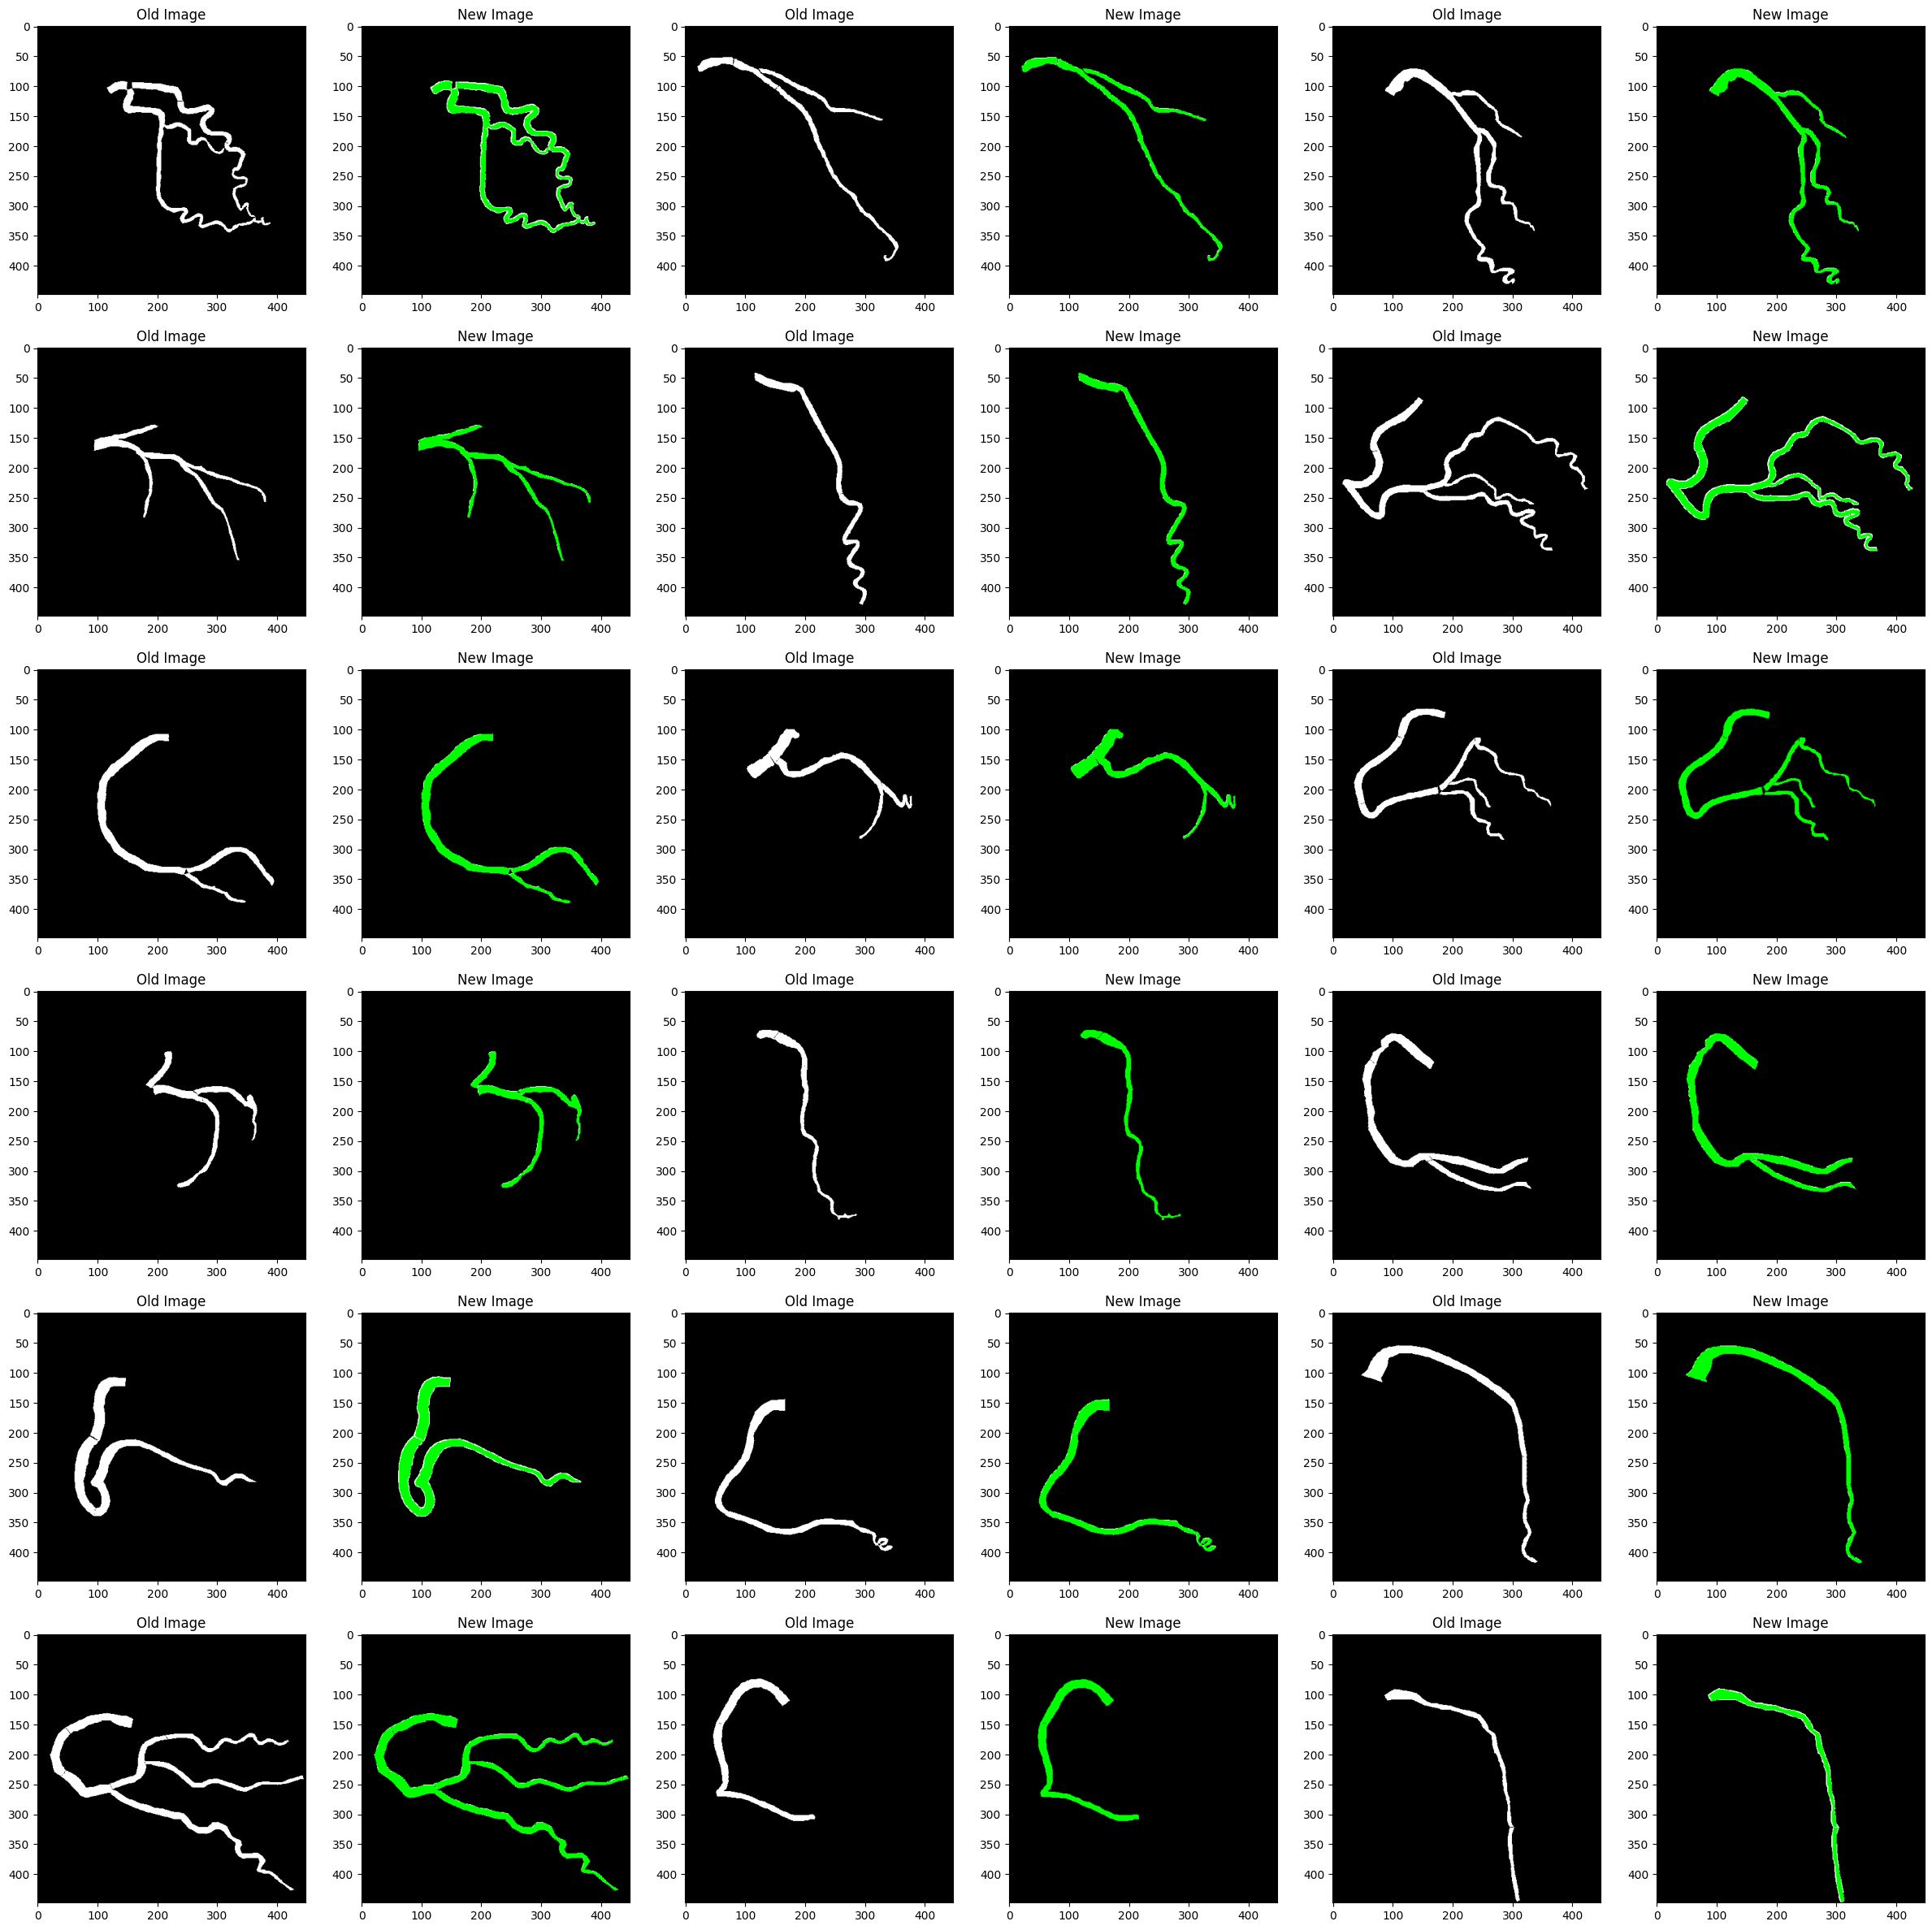

In [24]:
plot_some_images(train_images, train_transforms, image_counts=36, fig_shape=(6,6), base_transforms=test_transforms)

In [ ]:
model = nnUnet(args).to(args["device"])
loss_fn = UnetLoss(args)
# optimizer = torch.optim.Adam(model.parameters(), lr=args["lr"])
# optimizer = torch.optim.SGD(
#     model.parameters(),
#     momentum=args["momentum"],
#     lr=args["lr"],
#     nesterov=True,
#     weight_decay=args["weight_decay"]
# )
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=0.001, 
    betas=(0.9, 0.999), 
    eps=1e-08, 
    weight_decay=0.01
)
lr_sch = PolynomialLR(optimizer=optimizer,total_iters=args["epcohs"],power=0.9)
recorder = HistoryRecorder(losses_keys=losses_keys,class_maps =class_map)

best_model =trainer(
    args=args,
    recorder = recorder,
    model = model,
    optimizer = optimizer,
    loss_fn = loss_fn,
    train_loader = train_loader,
    valid_loader = valid_loader,
    loss_weights=loss_weights,
    lr_sch = lr_sch
)

number of layers : 6
encoder settings :  [32, 64, 128, 256, 512, 512]
bottle-neck settings :  1024
decoder settings :  [1024, 512, 256, 128, 64]
head settings :  26
loss is set to tversky


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

current lr : 0.001
train ==> epcoh (0)
total loss : 3.625023531913757 - CE loss : 1.6837171357870102 - tversky loss : 1.9413064098358155

train avg metrics for epoch 0 :
avg dice : 0.009582479239415988 - avg precision : 0.011017354815630825 - avg recall : 0.054941104850468034
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (0)
total loss : 1.5627542376518249 - CE loss : 0.5780796855688095 - tversky loss : 0.9846745610237122

valid avg metrics for epoch 0 :
avg dice : 0.0075055919272600975 - avg precision : 0.023999587190337478 - avg recall : 0.06331961480587779
------------------------------------------------------------
New Best! : dice = 0.007505591493099928


  0%|          | 0/100 [00:00<?, ?it/s]

...

--- Total Norm ---
tensor(0.3846, device='cuda:0')
current lr : 2.283e-05
train ==> epcoh (197)
total loss : 0.37178697615861894 - CE loss : 0.0981485864892602 - tversky loss : 0.27363839171826837

train avg metrics for epoch 197 :
avg dice : 0.8075473833084107 - avg precision : 0.7595687651634216 - avg recall : 0.8691882610321044
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (197)
total loss : 0.6291111722588539 - CE loss : 0.37872278578579427 - tversky loss : 0.2503883928060532

valid avg metrics for epoch 197 :
avg dice : 0.5842192612588406 - avg precision : 0.5794158012419939 - avg recall : 0.6144986534118653
------------------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

current lr : 1.585e-05
train ==> epcoh (198)
total loss : 0.3626264441013336 - CE loss : 0.0984572758898139 - tversky loss : 0.26416916817426683

train avg metrics for epoch 198 :
avg dice : 0.8045385241508484 - avg precision : 0.7556800723075867 - avg recall : 0.8665256404876709
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (198)
total loss : 0.6321513742208481 - CE loss : 0.38134785518050196 - tversky loss : 0.250803516805172

valid avg metrics for epoch 198 :
avg dice : 0.5838999465107918 - avg precision : 0.5796260087937116 - avg recall : 0.6149035063385964
------------------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

current lr : 8.493e-06
train ==> epcoh (199)
total loss : 0.37674535393714903 - CE loss : 0.09918585278093815 - tversky loss : 0.277559504956007

train avg metrics for epoch 199 :
avg dice : 0.8029023098945618 - avg precision : 0.7533612918853759 - avg recall : 0.8676996994018554
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (199)
total loss : 0.6329236447811126 - CE loss : 0.3814805045723915 - tversky loss : 0.251443137973547

valid avg metrics for epoch 199 :
avg dice : 0.5820191793888807 - avg precision : 0.5758583077788353 - avg recall : 0.614124237857759
1 => dice : 0.885563313961029 p : 0.8774705529212952 , r : 0.8938067555427551
2 => dice : 0.7950286865234375 p : 0.8091853857040405 , r : 0.7813588380813599
3 => dice : 0.8226668238639832 p : 0.7746328711509705 , r : 0.8770515322685242
4 => dice : 0.8636541962623596 p : 0.8573739528656006 , r : 0.8700271844863892
5 => dice : 0.887289822101593 p : 0.8987993001937866 , r : 0.8760713338851929
6 => dice 

Save Model
Saving Memory
Saving All Plots


  0%|          | 0/20 [00:00<?, ?it/s]

Saving Examples


  0%|          | 0/18 [00:00<?, ?it/s]

Saving Verbal Results
Copying Notebook To Results
builfding kaggle project


100%|██████████| 9/9 [00:00<00:00, 1889.89it/s]


processing ./utils/dataset.py
processing ./utils/helpers.py
processing ./logger.py
processing ./utils/preprocessing.py
processing ./utils/recorder.py
processing ./models/costume_nnunet_blocks.py
processing ./models/nnunet.py
processing ./utils/losses.py
processing ./trainer.py


100%|██████████| 1/1 [00:00<00:00,  2.32it/s]

processing ./temp_script.py


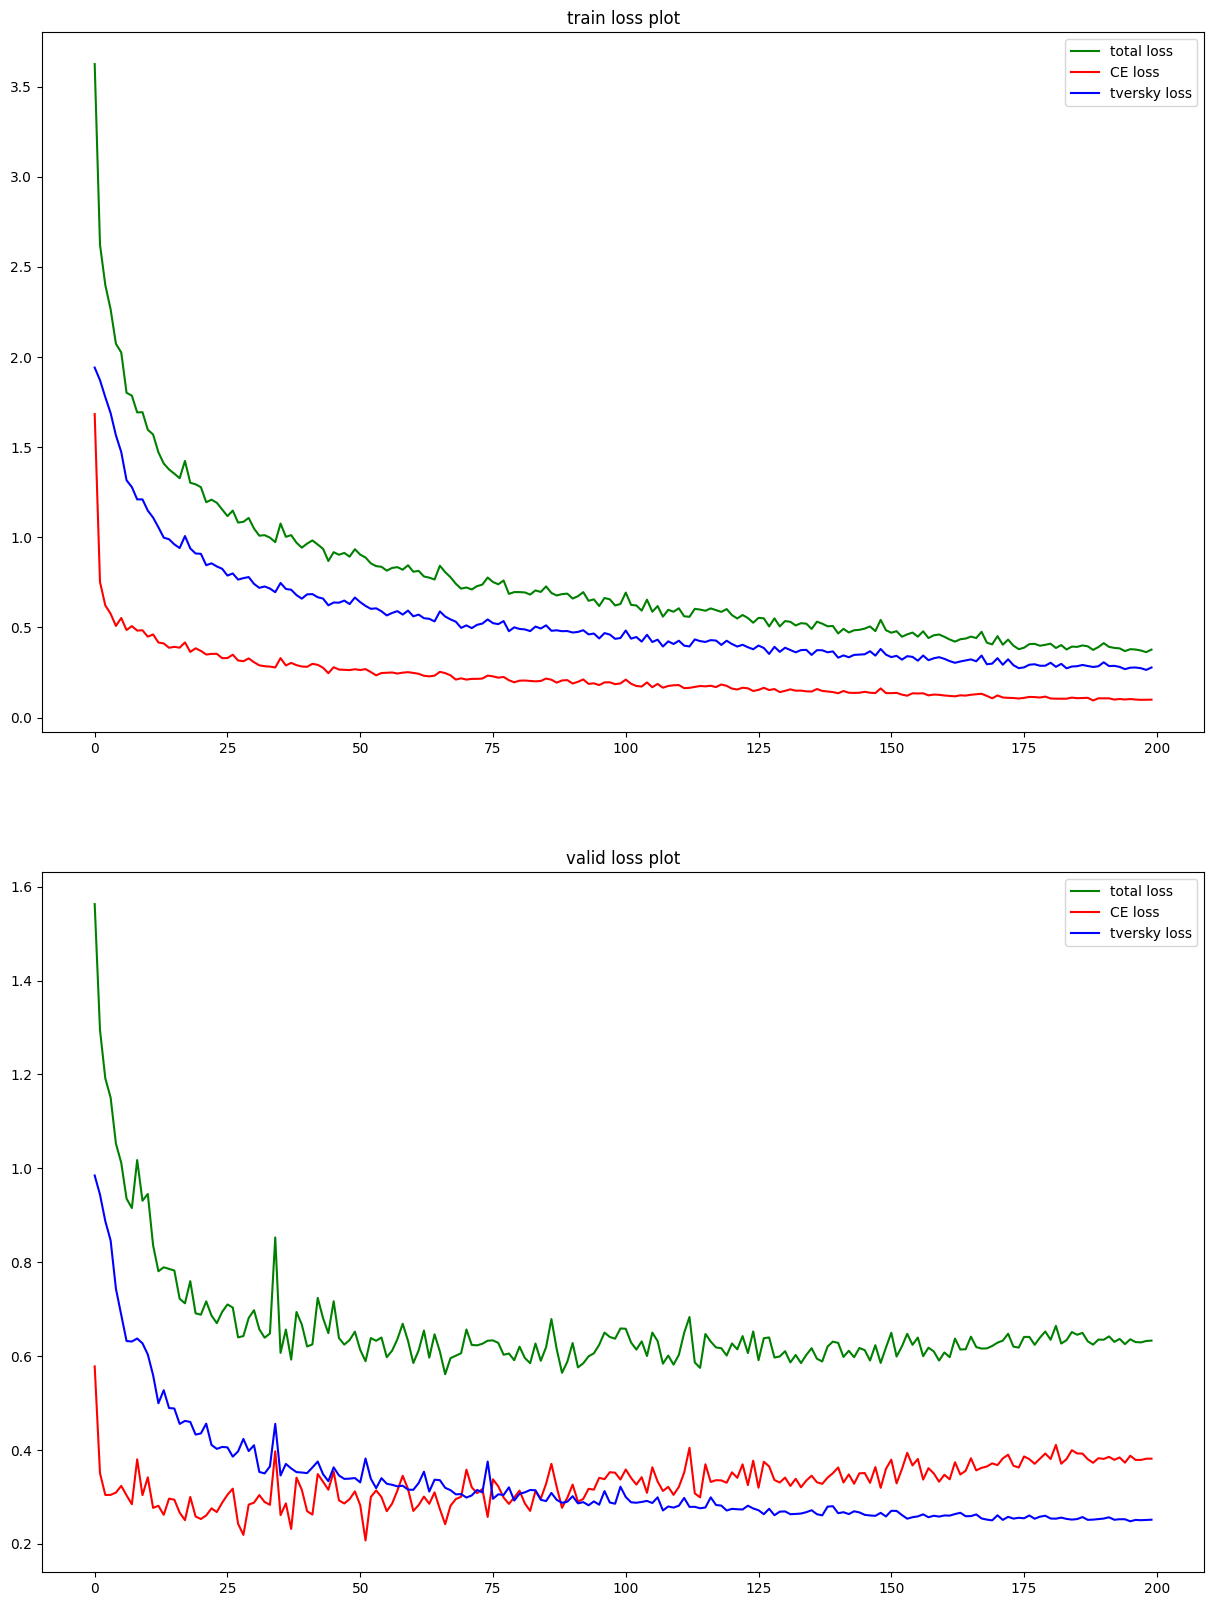

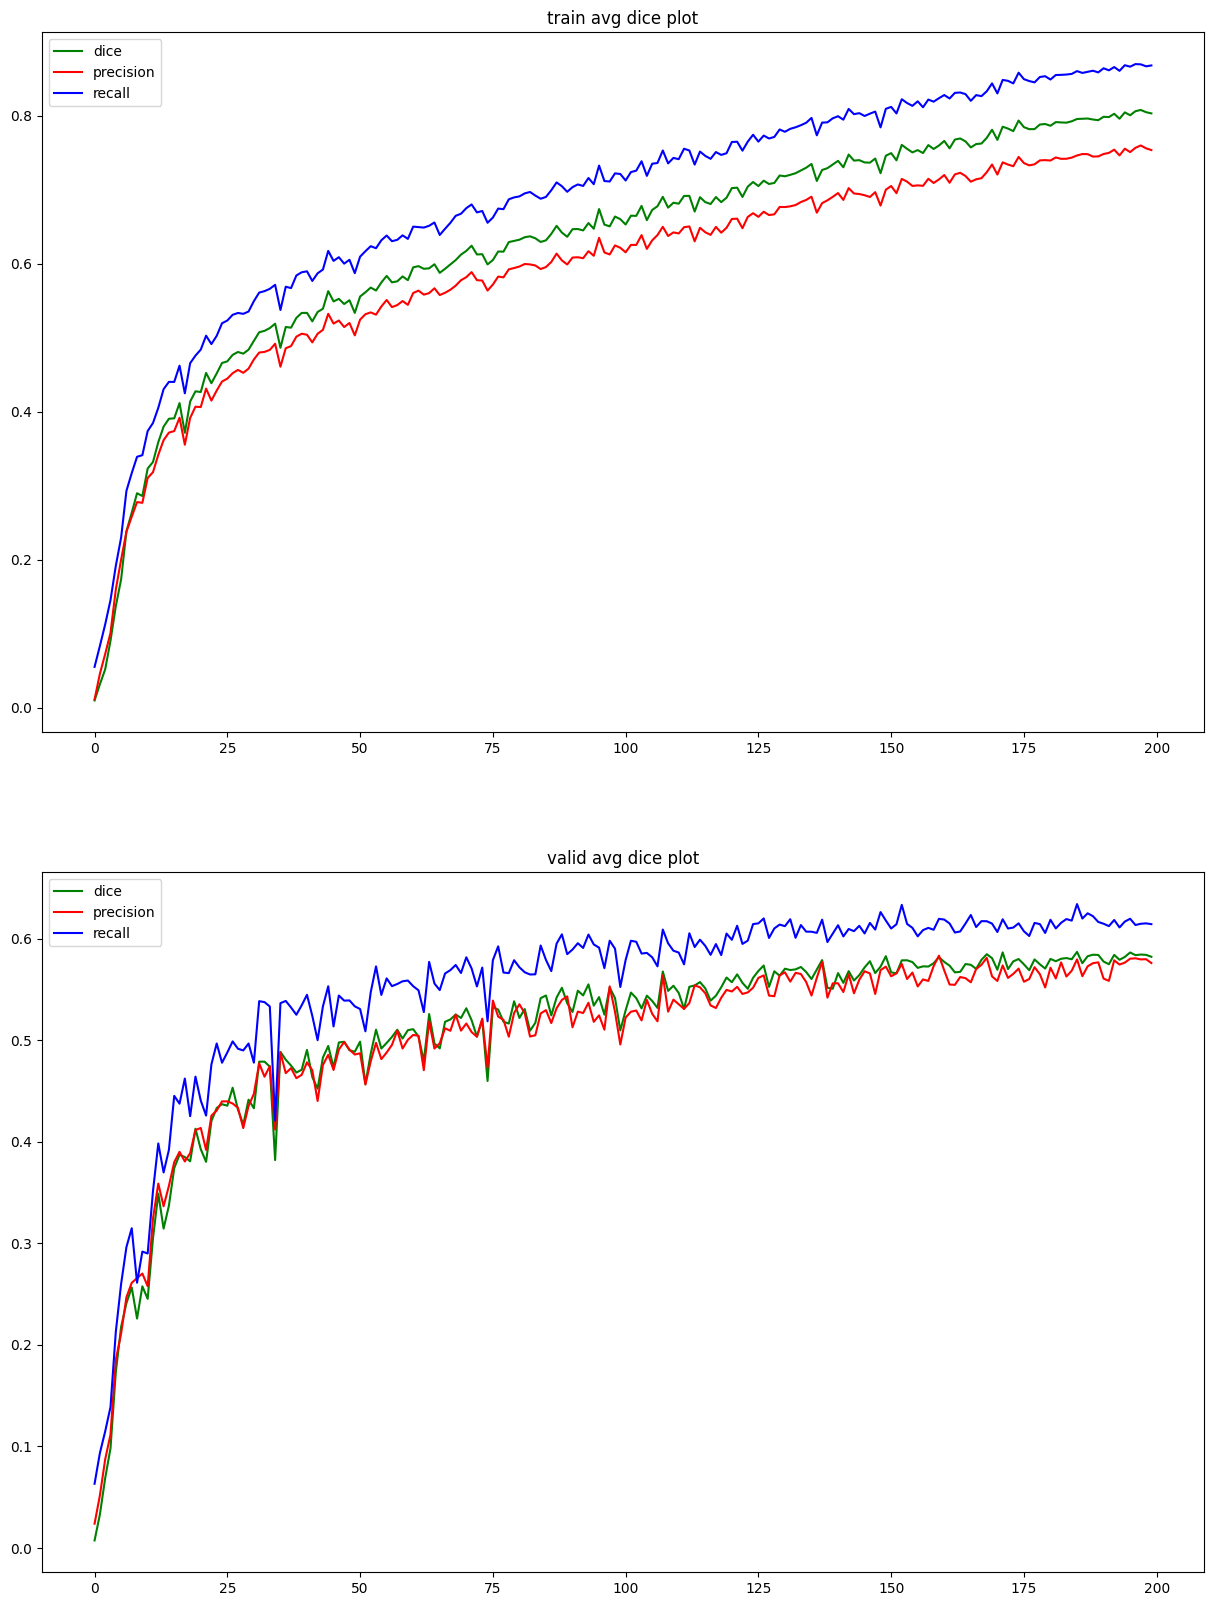

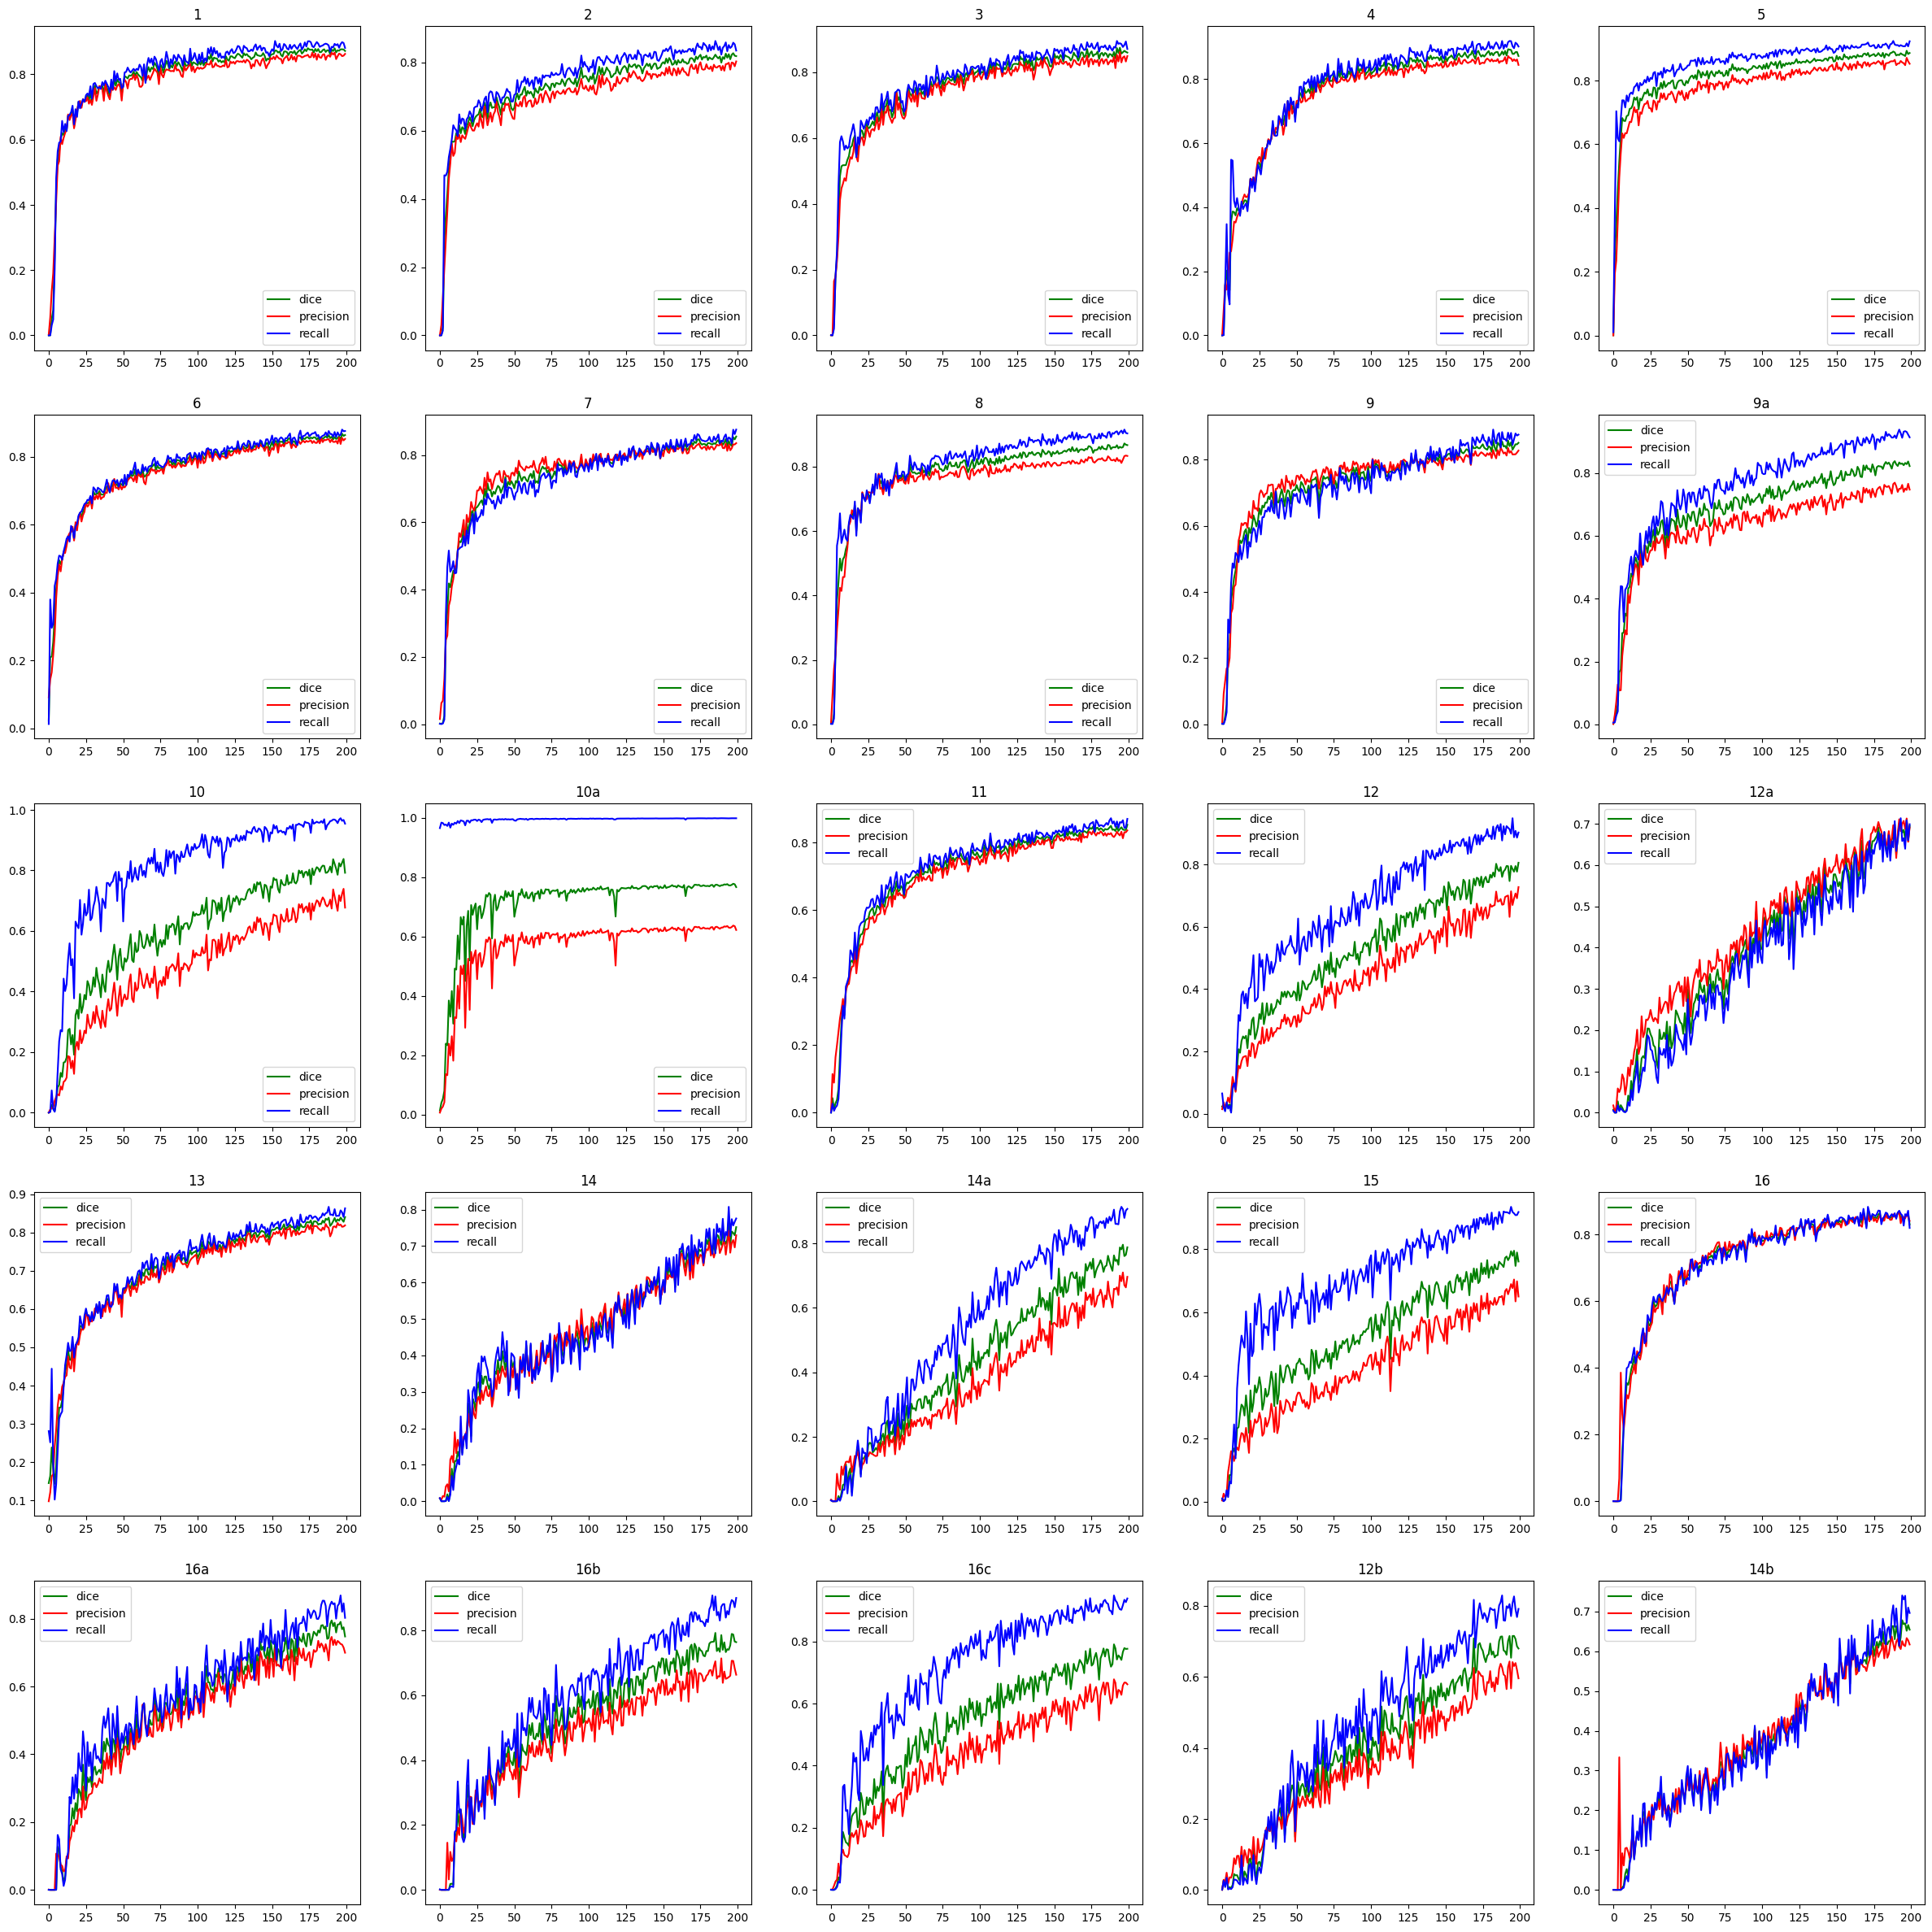

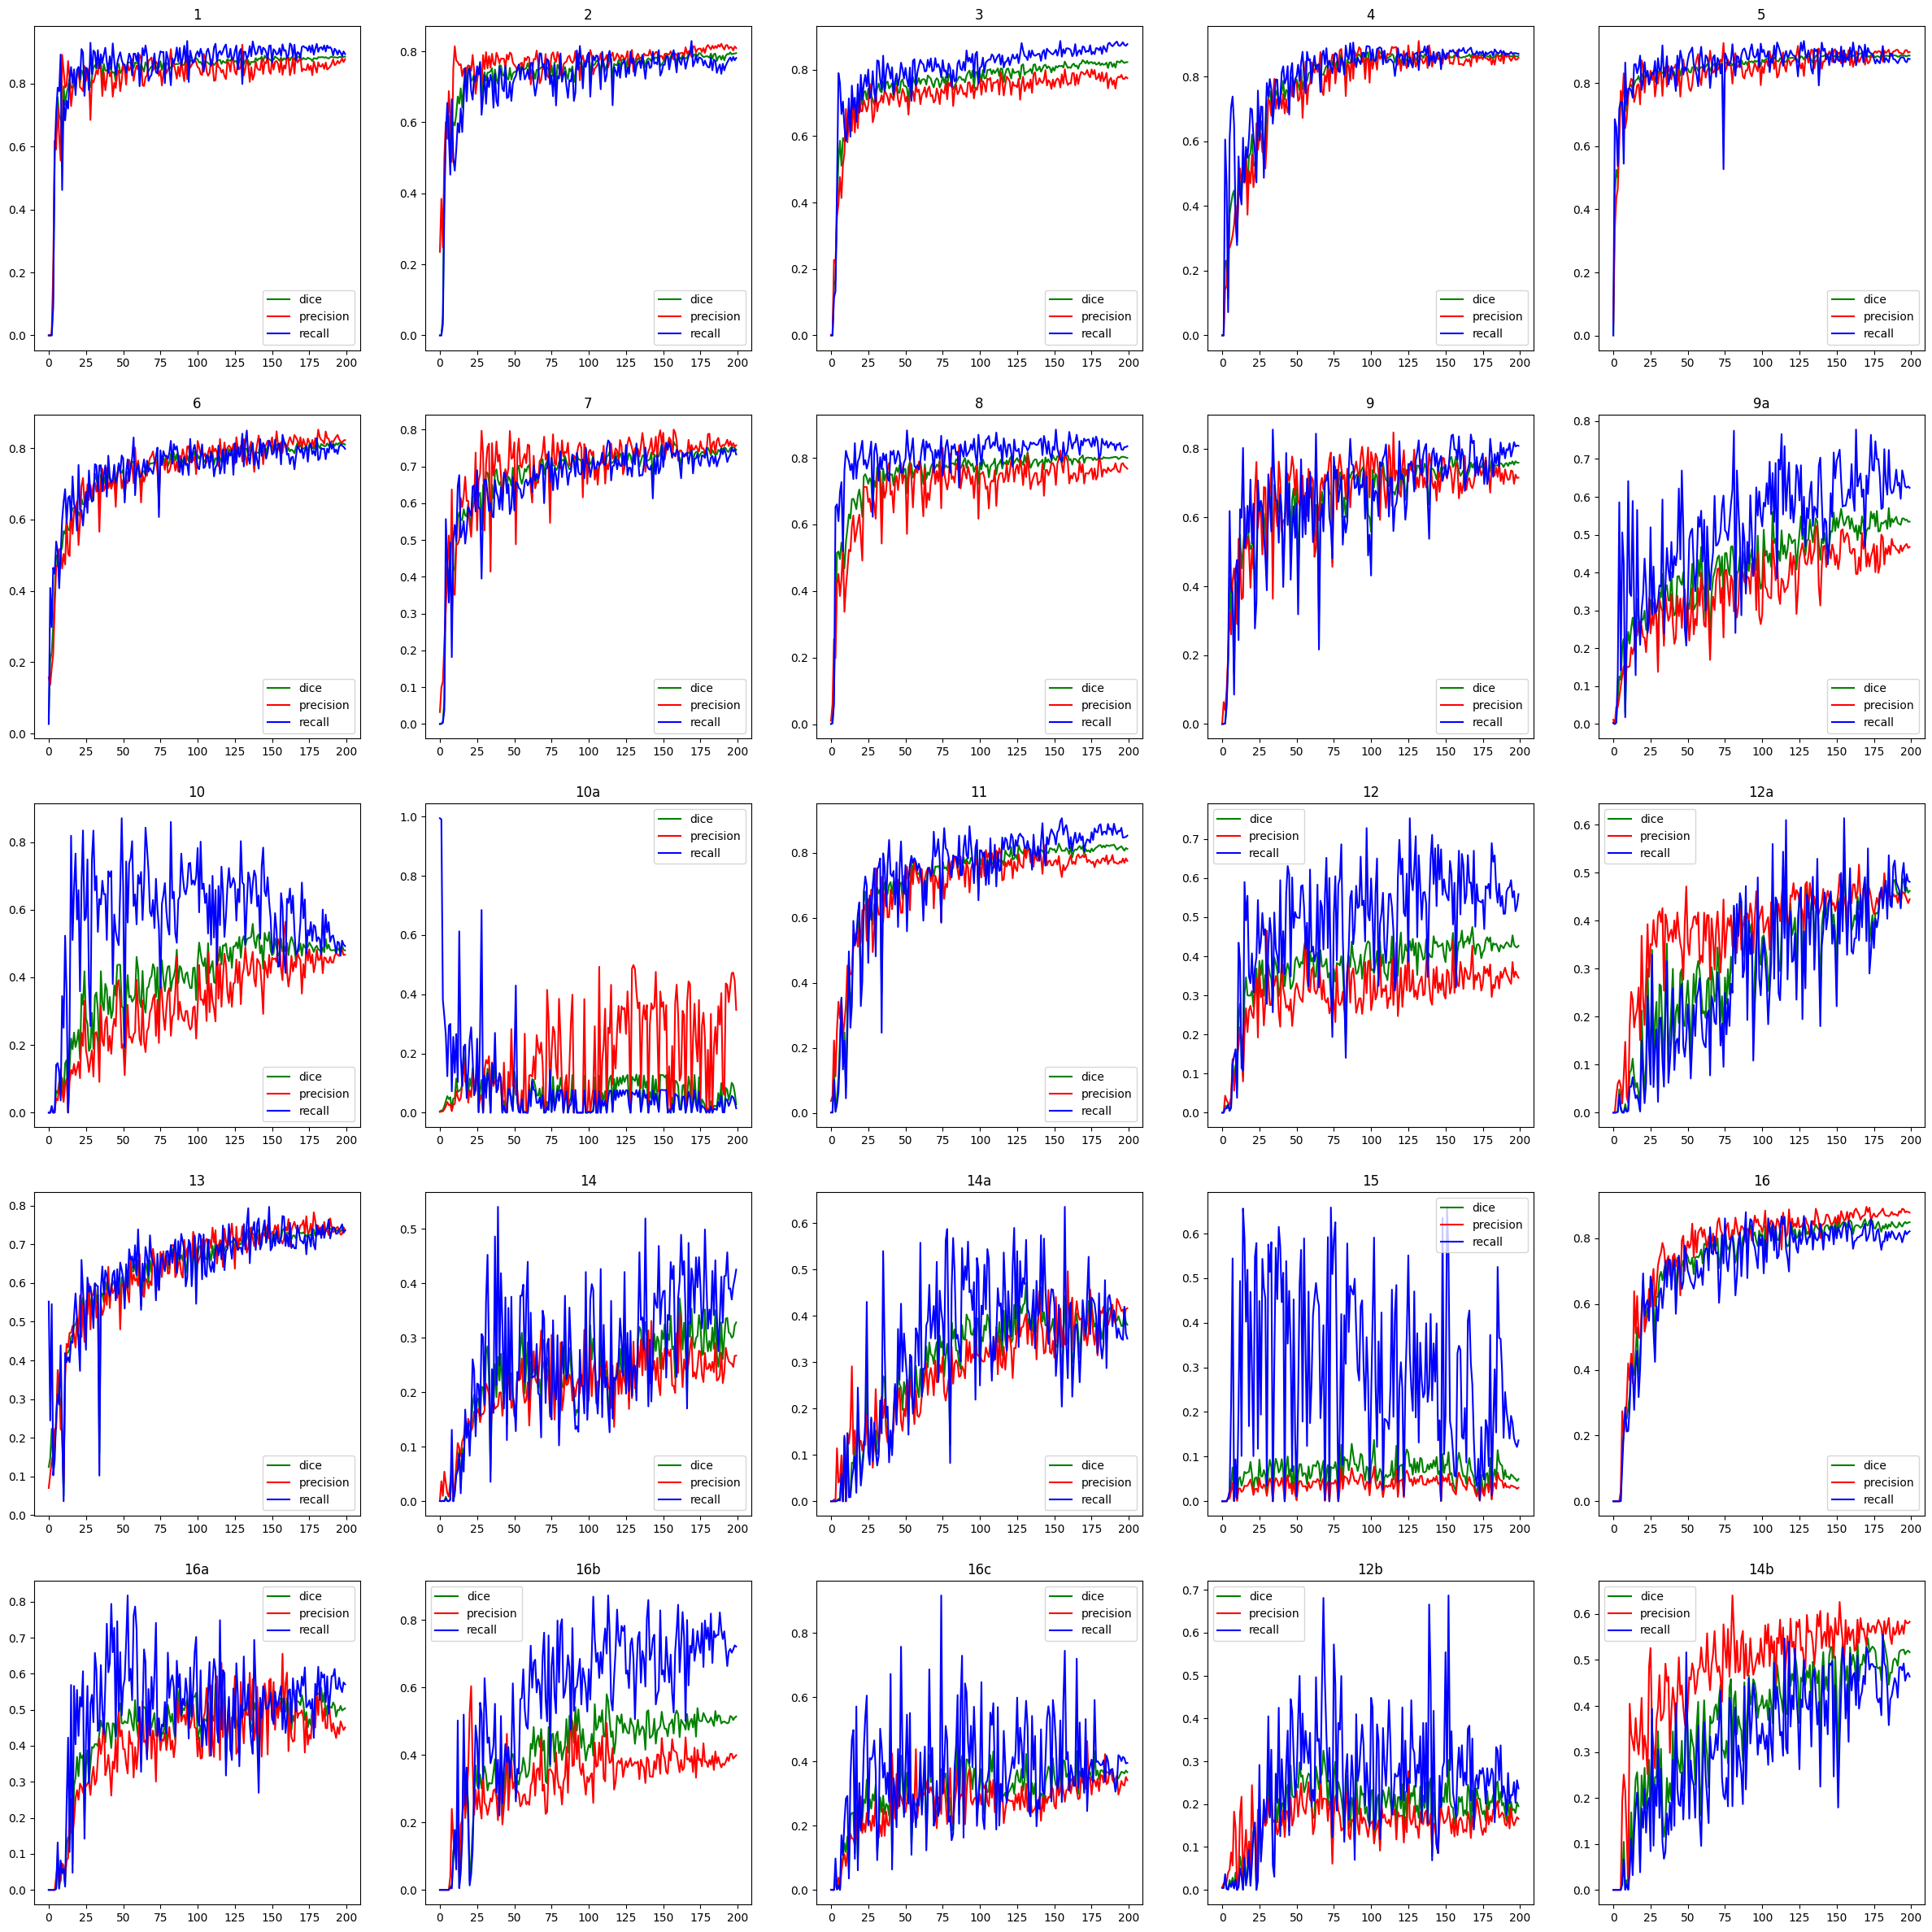

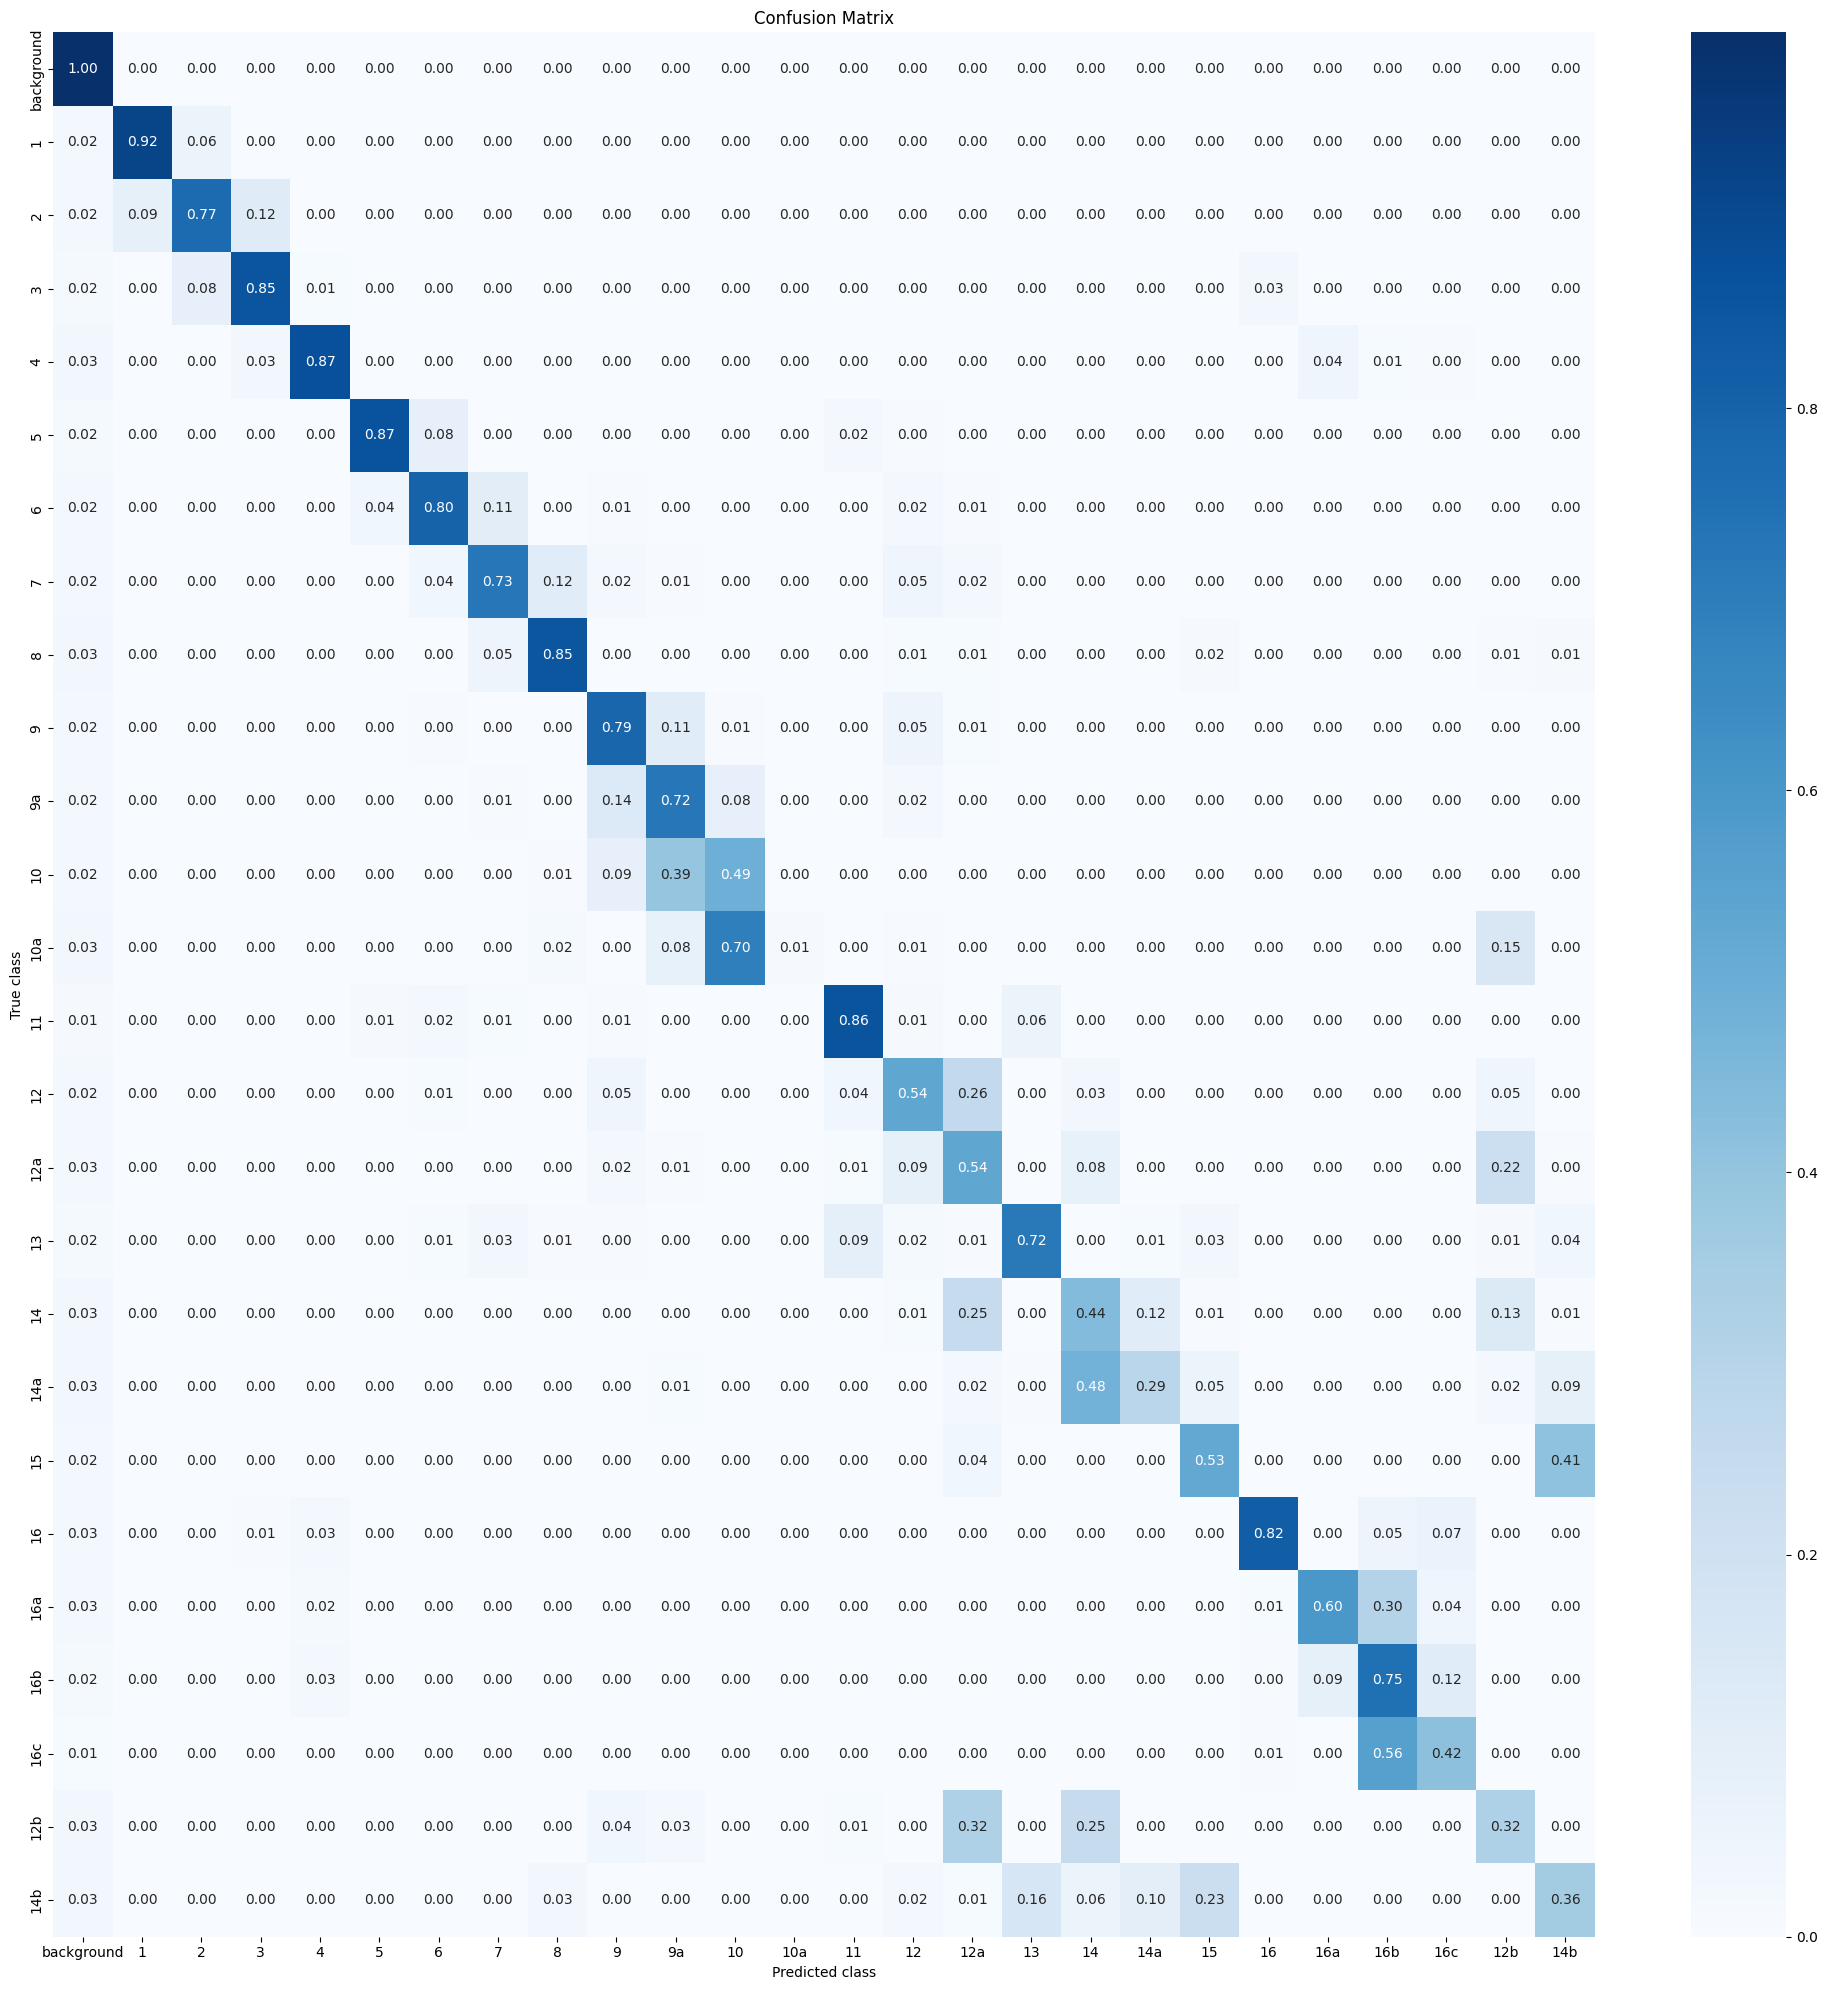

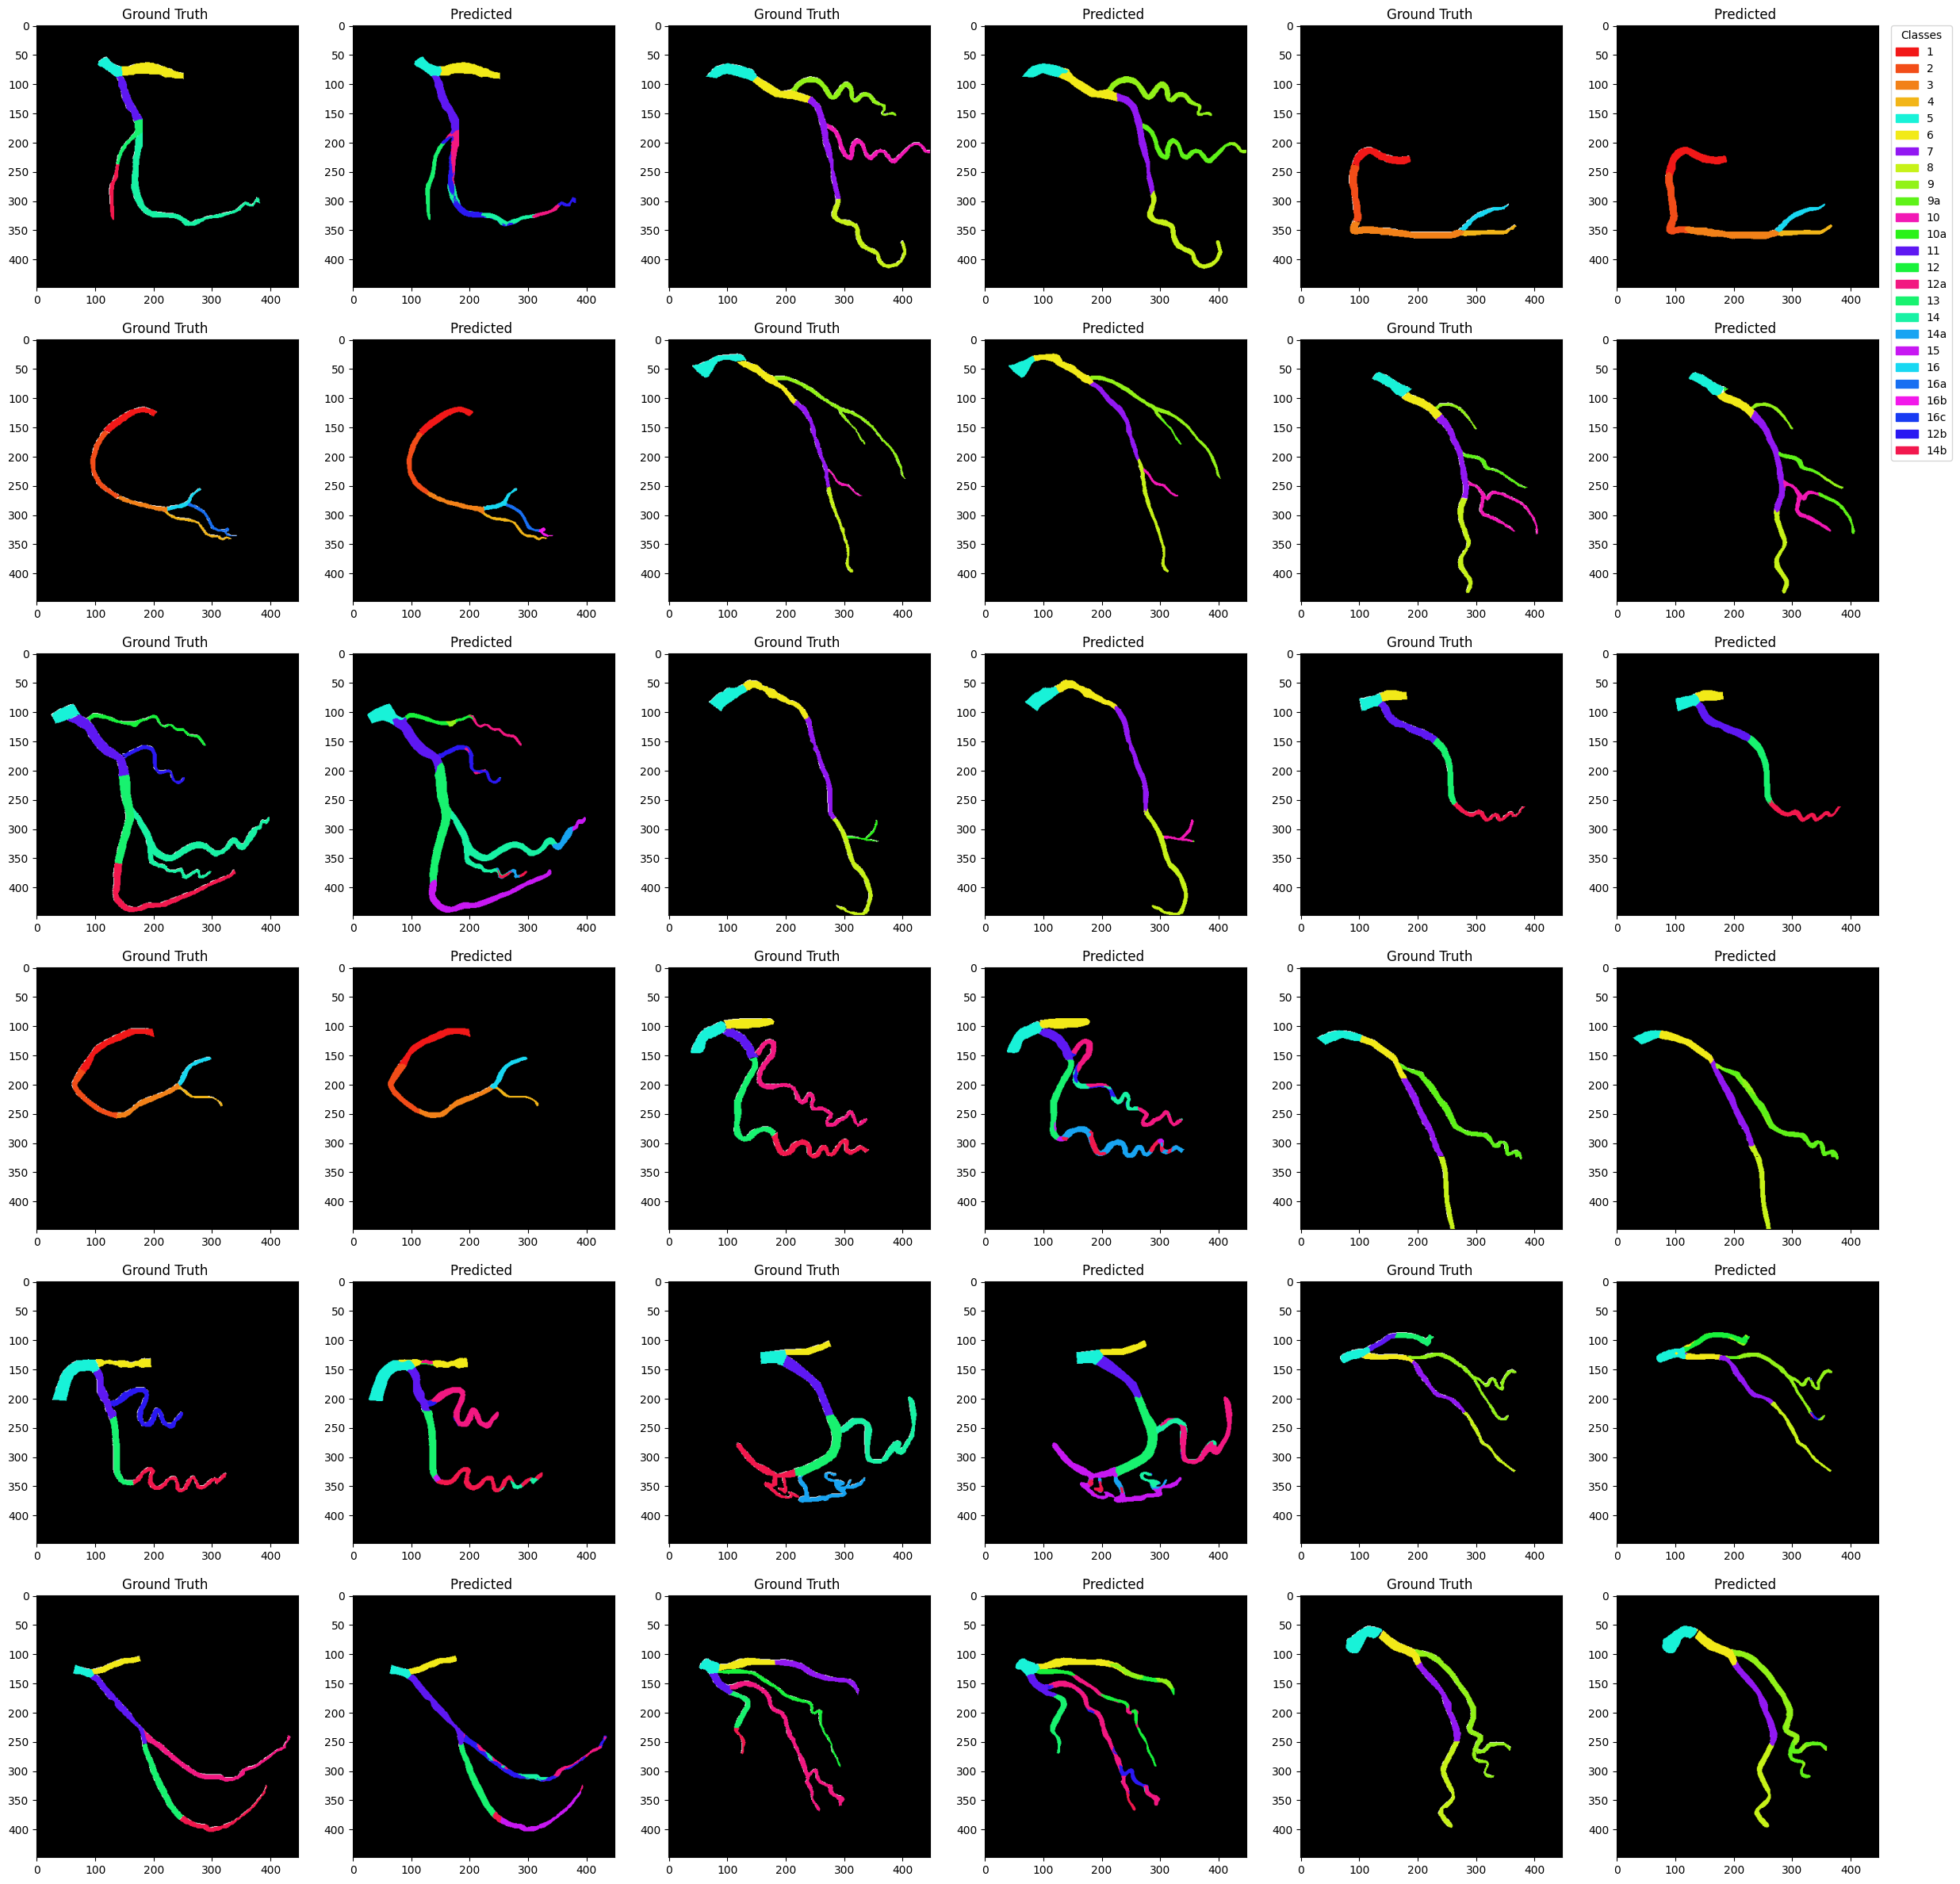

In [ ]:
save_full_report(
    recorder= recorder , 
    output_base_path=args["output_base_path"],
    model=best_model,
    valid_loader=valid_loader,
    args=args,
    class_map=class_map,
    name=args["name"]
)